<a href="https://colab.research.google.com/github/savinthie/Final_Year_Project_IDP_2024-2025/blob/main/Camera_Ready_Paper_(DeepBoost).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer

import numpy as np

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, ReLU, Concatenate, MaxPooling1D,Dropout,BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
import joblib

from scipy.special import expit as sigmoid
import matplotlib.pyplot as plt
import joblib


In [ ]:
# Data Collection
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/FYP 2024 25/USDataset.csv', header=1)
df = df.fillna(0)

# Data Preprocessing
df.columns = [col.lower().replace(' ', '').replace('.', '') for col in df.columns]
cols_to_keep = ['stateabv', 'county', 'family', 'housing', 'food', 'transportation',
                'healthcare', 'othernecessities', 'childcare', 'taxes', 'total',
                'median_family_income', 'num_counties_in_st']
df1 = df[cols_to_keep].copy()

df1['median_family_income'] = df1['median_family_income'].replace(',', '', regex=True).astype(float)

# Feature Engineering
df1['n_parents'] = df1['family'].str.slice(0, 1).astype(int)
df1['n_children'] = df1['family'].str.slice(2, 3).astype(int)
df1['n_members'] = df1['n_parents'] + df1['n_children']

df1['financial_stability'] = df1['median_family_income'] / df1['total']


df1["per_member_cost"] = df1["total"] / df1["n_members"]
df1["child_expense_cost"] = df1["per_member_cost"]*df1["n_children"]
df1["parent_expense_cost"] = df1["per_member_cost"]*df1["n_parents"]
df1["other_expense_cost"] = df1["total"] - (df1["child_expense_cost"]+df1["parent_expense_cost"])




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Splitting the data
X = df1[['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents', 'n_members']+['per_member_cost','child_expense_cost','parent_expense_cost','other_expense_cost']].values
y_expenses = df1[['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']].values

target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']

# Scaling
scaler_X = StandardScaler()

# Load the X scaler
# scaler_X = joblib.load('scaler_X.pkl')

X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()

# Load the y scaler
# scaler_y = joblib.load('scaler_y.pkl')
y_exp_scaled = scaler_y.fit_transform(y_expenses)



# Save the X scaler
joblib.dump(scaler_X, 'scaler_X.pkl')

# Save the y scaler
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

In [ ]:
df1

,stateabv,county,family,housing,food,transportation,healthcare,othernecessities,childcare,taxes,...,median_family_income,num_counties_in_st,n_parents,n_children,n_members,financial_stability,per_member_cost,child_expense_cost,parent_expense_cost,other_expense_cost
0,AL,Autauga County,1p0c,817,335,1110,510,408,0,624,...,83790.0,67,1,0,1,22.032606,3803.000000,0.000000,3803.000000,0.0
1,AL,Autauga County,1p1c,1114,494,1365,756,570,520,761,...,83790.0,67,1,1,2,15.016129,2790.000000,2790.000000,2790.000000,0.0
2,AL,Autauga County,1p2c,1114,723,1570,1003,651,1012,949,...,83790.0,67,1,2,3,11.934197,2340.333333,4680.666667,2340.333333,0.0
3,AL,Autauga County,1p3c,1416,966,1670,1249,843,1163,1234,...,83790.0,67,1,3,4,9.810327,2135.250000,6405.750000,2135.250000,0.0
4,AL,Autauga County,1p4c,1416,1182,1742,1495,920,1163,1474,...,83790.0,67,1,4,5,8.921422,1878.400000,7513.600000,1878.400000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31425,WY,Weston County,2p0c,741,637,1613,1304,488,0,669,...,80178.0,23,2,0,2,14.708861,2725.500000,0.000000,5451.000000,0.0
31426,WY,Weston County,2p1c,975,793,1791,1698,626,559,798,...,80178.0,23,2,1,3,11.074309,2413.333333,2413.333333,4826.666667,0.0
31427,WY,Weston County,2p2c,975,1003,1911,2091,700,1096,879,...,80178.0,23,2,2,4,9.262708,2164.000000,4328.000000,4328.000000,0.0
31428,WY,Weston County,2p3c,1187,1225,2074,2485,854,1261,1063,...,80178.0,23,2,3,5,7.898532,2030.200000,6090.600000,4060.400000,0.0


In [ ]:
# Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=100)

# Metrics
def print_metrics(y_true, y_pred, task_name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{task_name} - MSE: {mse:.4f}, R2: {r2:.4f}")

def regr_report(x, y):
    mae = round(mean_absolute_error(x, y), 4)
    r2 = round(r2_score(x, y), 4)
    mse = round(mean_squared_error(x, y), 4)
    rmse = round(np.sqrt(mean_squared_error(x, y)), 4)
    return f'MAE: {mae}, R-Squared: {r2}, RMSE: {rmse}, MSE: {mse}'

**ANN architecture - (Benchmark)**

In [ ]:
def ANN_model(input_shape, target_col_list):
    input_layer = Input(shape=input_shape)


    # ANN part
    # Adding Batch Normalization, Dropout, and Flexible Activation Layers
    x = Dense(128)(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)  # Dropout for regularization

    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    # Output Layers (for multiple targets)
    output_layers = [Dense(1, activation='linear', name=f'target_{col}')(x) for col in target_col_list]

    # Model Compilation
    model = Model(inputs=input_layer, outputs=output_layers)
    return model


Fold 1/5
Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 4.4598 - target_childcare_loss: 0.5507 - target_food_loss: 0.4894 - target_healthcare_loss: 0.7336 - target_housing_loss: 0.7259 - target_othernecessities_loss: 0.5516 - target_taxes_loss: 0.6795 - target_transportation_loss: 0.7291 - val_loss: 1.0281 - val_target_childcare_loss: 0.1151 - val_target_food_loss: 0.0474 - val_target_healthcare_loss: 0.1992 - val_target_housing_loss: 0.1599 - val_target_othernecessities_loss: 0.0766 - val_target_taxes_loss: 0.0721 - val_target_transportation_loss: 0.3524
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.6538 - target_childcare_loss: 0.1975 - target_food_loss: 0.1422 - target_healthcare_loss: 0.2813 - target_housing_loss: 0.2737 - target_othernecessities_loss: 0.1685 - target_taxes_loss: 0.1850 - target_transportation_loss: 0.4057 - val_loss: 0.9391 - val_target_childcare_loss: 0.0929 - val_target_food_loss: 0.0437 - val_target_healthcare_loss: 0.1818 - val_t

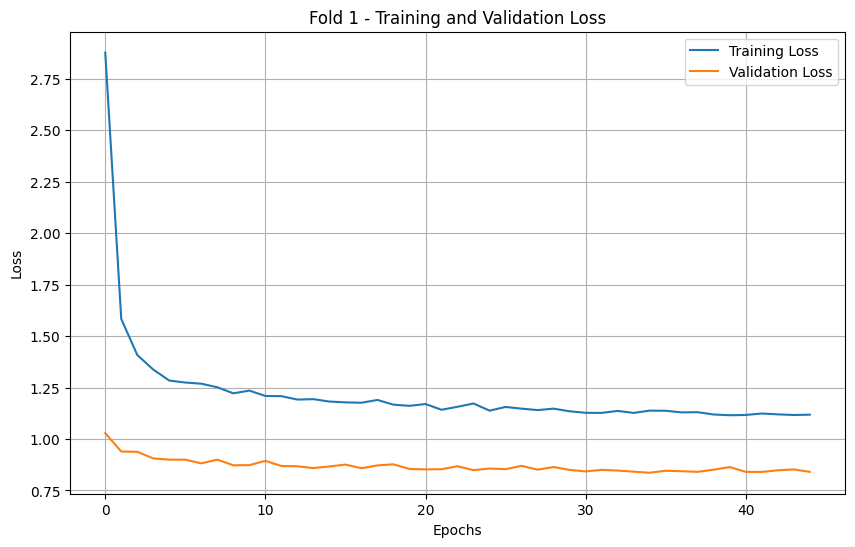

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 1):
Train Data: {'MSE': 17654.89535986446, 'R2': 0.8816071834667124, 'MAE': 93.2067546158735, 'RMSE': 132.87172520842972}
Validation Data: {'MSE': 17538.53167541452, 'R2': 0.8767564946422095, 'MAE': 92.83632864543976, 'RMSE': 132.4331215195599}
Test Data: {'MSE': 17352.377243342537, 'R2': 0.8825063031973371, 'MAE': 93.007398342578, 'RMSE': 131.72842230643522}

Model Results for Food (Fold 1):
Train Data: {'MSE': 4745.830452363631, 'R2': 0.9593036573961259, 'MAE': 46.18869475638681, 'RMSE': 68.88998804154078}
Validation Data: {'MSE': 4054.498821664426, 'R2': 0.9645112953831949, 'MAE': 44.25388126694925, 'RMSE': 63.67494657763307}
Test Data: {'MSE': 5541.621163818124, 'R2': 0.9527906146612684, 'MAE': 47.375721527594806, 'RMSE': 74.44206582180618}

Model Results for Transportation (Fold 1):
Train Data: {'MSE': 17636.5386014098, 'R2': 0.6864

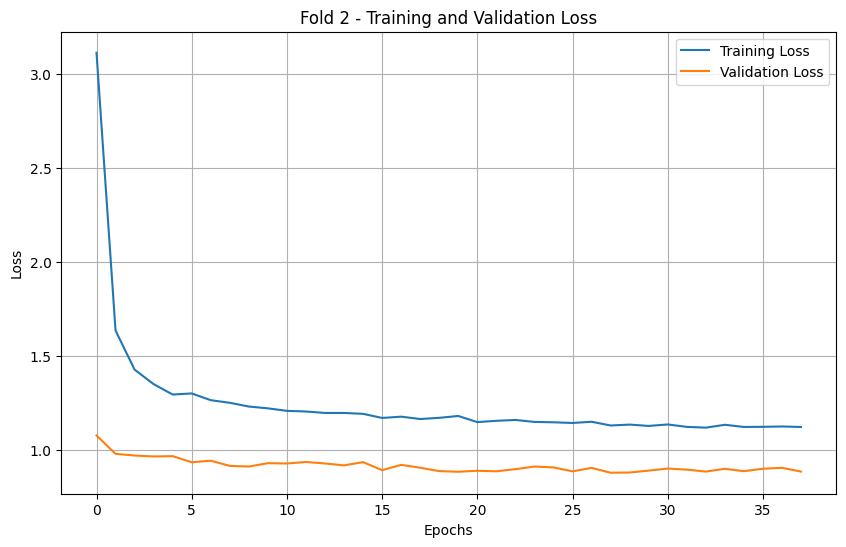

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Model Results for Housing (Fold 2):
Train Data: {'MSE': 17435.998645537777, 'R2': 0.8789242523680073, 'MAE': 92.73401292053863, 'RMSE': 132.0454415931795}
Validation Data: {'MSE': 19126.052070727113, 'R2': 0.8840729513601017, 'MAE': 95.84387142947249, 'RMSE': 138.2969705768247}
Test Data: {'MSE': 18911.23262756442, 'R2': 0.8859175932475277, 'MAE': 95.03529888545106, 'RMSE': 137.51811745208127}

Model Results for Food (Fold 2):
Train Data: {'MSE': 4820.902054987882, 'R2': 0.9583820621677354, 'MAE': 47.2791260583667, 'RMSE': 69.43271602773352}
Validation Data: {'MSE': 4478.663824138122, 'R2': 0.963161114566658, 'MAE': 46.49397057907391, 'RMSE': 66.92281990575503}
Test Data: {'MSE': 4805.312380193656, 'R2': 0.9587022871041668, 'MAE': 47.59236571760721, 'RMSE': 69.32036050247905}

Model Results for Transportation (Fold 2):
Train Data: {'MSE': 17759.553053592652, 'R2': 0.68

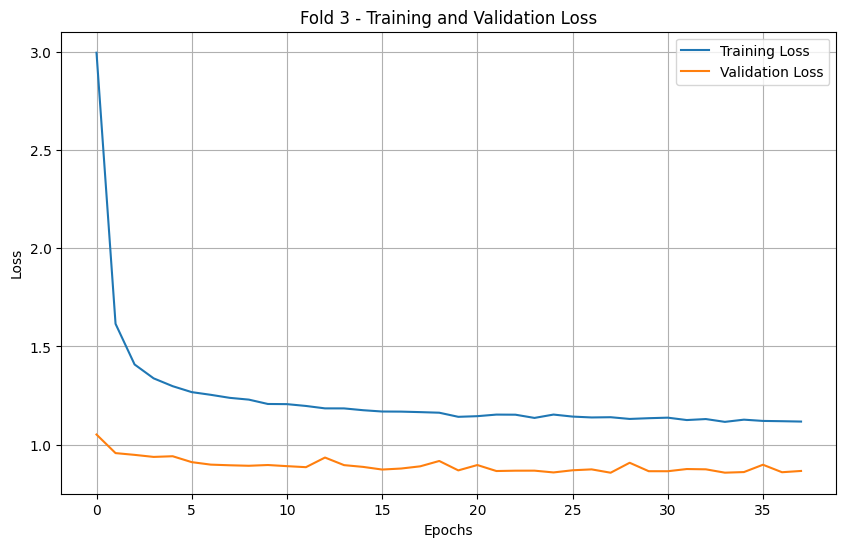

786/786 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 3):
Train Data: {'MSE': 17591.912947577715, 'R2': 0.8821516736527031, 'MAE': 92.97958413590453, 'RMSE': 132.6345088865553}
Validation Data: {'MSE': 17871.14214173993, 'R2': 0.8752287325084042, 'MAE': 93.25187896233321, 'RMSE': 133.6829912207979}
Test Data: {'MSE': 18104.904527895247, 'R2': 0.8756264566656822, 'MAE': 94.06102486397103, 'RMSE': 134.55446677050617}

Model Results for Food (Fold 3):
Train Data: {'MSE': 4693.778483431143, 'R2': 0.9598115078385394, 'MAE': 46.013949736189474, 'RMSE': 68.51115590494108}
Validation Data: {'MSE': 5297.652427371958, 'R2': 0.9550919454960317, 'MAE': 47.752450844075625, 'RMSE': 72.78497391200987}
Test Data: {'MSE': 4736.525617932284, 'R2': 0.957823145630935, 'MAE': 45.703163450400695, 'RMSE': 68.82242089560846}

Model Results for Transportation (Fold 3):
Train Data: {'MSE': 17904.331665444563, 'R2': 

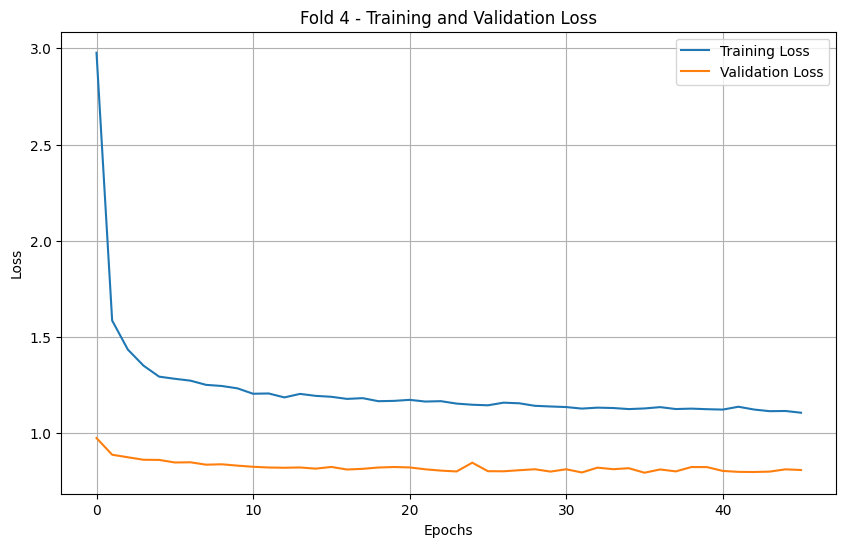

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Model Results for Housing (Fold 4):
Train Data: {'MSE': 17853.25481566542, 'R2': 0.8803336133388215, 'MAE': 92.78940961681806, 'RMSE': 133.61607244514195}
Validation Data: {'MSE': 17101.760231898374, 'R2': 0.8738202952711925, 'MAE': 91.04882074563017, 'RMSE': 130.77369854790516}
Test Data: {'MSE': 18347.898293172984, 'R2': 0.88068121322207, 'MAE': 94.7733538800882, 'RMSE': 135.45441407784756}

Model Results for Food (Fold 4):
Train Data: {'MSE': 4863.850435168907, 'R2': 0.9582622929805874, 'MAE': 46.79779906702239, 'RMSE': 69.74131082198633}
Validation Data: {'MSE': 4195.978489709629, 'R2': 0.963912822257496, 'MAE': 45.493927273824646, 'RMSE': 64.77637292801774}
Test Data: {'MSE': 4424.083798301511, 'R2': 0.9618401886565482, 'MAE': 46.06361599375099, 'RMSE': 66.51378652806883}

Model Results for Transportation (Fold 4):
Train Data: {'MSE': 17774.020033409182, 'R2': 0.6

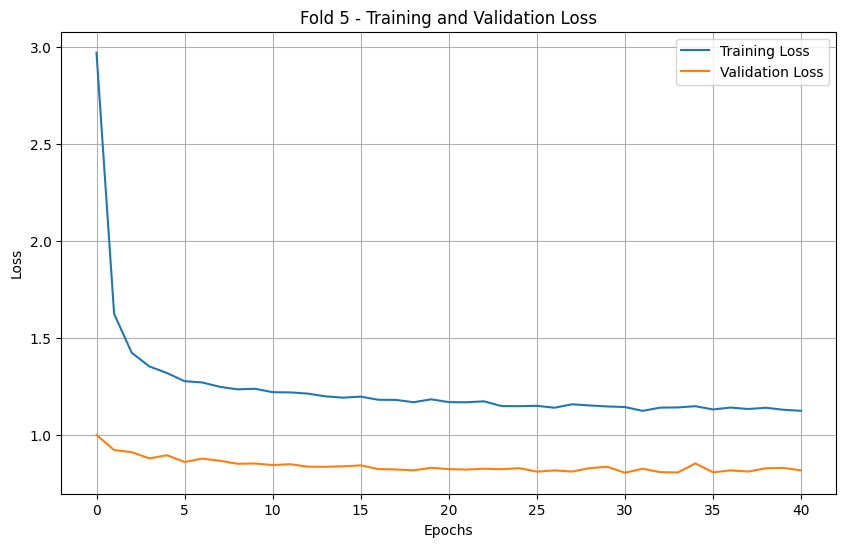

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 5):
Train Data: {'MSE': 17763.035368336412, 'R2': 0.8815066023876946, 'MAE': 92.44050479200742, 'RMSE': 133.27803783195645}
Validation Data: {'MSE': 17048.080508966195, 'R2': 0.8710935650125909, 'MAE': 91.67011663210532, 'RMSE': 130.56829825407925}
Test Data: {'MSE': 17371.026521282583, 'R2': 0.8853197470973974, 'MAE': 91.58466650064379, 'RMSE': 131.79919013894806}

Model Results for Food (Fold 5):
Train Data: {'MSE': 4696.4520492784295, 'R2': 0.9596990990944841, 'MAE': 46.55484230534271, 'RMSE': 68.53066502871856}
Validation Data: {'MSE': 5649.131240570639, 'R2': 0.9514897781243767, 'MAE': 48.76869964356867, 'RMSE': 75.16070276794011}
Test Data: {'MSE': 4553.793081674472, 'R2': 0.9606925938725605, 'MAE': 46.442811767500444, 'RMSE': 67.48179815086786}

Model Results for Transportation (Fold 5):
Train Data: {'MSE': 18176.394181077907, 'R2

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define function to plot training and validation loss curves
def plot_loss_curves(history, fold):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} - Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define evaluation function for regression metrics
def regr_report(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Cross-validation with ANN evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y, num_epochs=200):
    fold = 1
    target_metrics = {target: {"train": [], "val": [], "test": []} for target in target_col_list}

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data (50/50 split of remaining 20%)
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )

        # Create and compile the ANN model
        model = ANN_model((X_train.shape[1],), target_col_list)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

        # Early stopping callback
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # Train the model
        history = model.fit(
            X_train,
            [y_train[:, i] for i in range(y_train.shape[1])],
            validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
            epochs=num_epochs,
            batch_size=64,
            verbose=1,
            callbacks=[early_stopping]
        )
        plot_loss_curves(history, fold)

        # Predictions
        y_train_pred = np.column_stack(model.predict(X_train))
        y_val_pred = np.column_stack(model.predict(X_val))
        y_test_pred = np.column_stack(model.predict(X_test))

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()} (Fold {fold}):')
            train_metrics = regr_report(y_train_original[:, i], y_train_pred_original[:, i])
            val_metrics = regr_report(y_val_original[:, i], y_val_pred_original[:, i])
            test_metrics = regr_report(y_test_original[:, i], y_test_pred_original[:, i])

            print("Train Data:", train_metrics)
            print("Validation Data:", val_metrics)
            print("Test Data:", test_metrics)
            print()

            # Append metrics for the target
            target_metrics[target]["train"].append(train_metrics)
            target_metrics[target]["val"].append(val_metrics)
            target_metrics[target]["test"].append(test_metrics)

        fold += 1

    # Final evaluation: average metrics for each target across folds
    print("\nFinal Evaluation Across All Folds for Each Target:")
    for target, metrics in target_metrics.items():
        print(f"\nTarget: {target.capitalize()}")
        for dataset, dataset_metrics in metrics.items():
            avg_metrics = {k: np.mean([fold_metrics[k] for fold_metrics in dataset_metrics]) for k in dataset_metrics[0]}
            print(f"{dataset.capitalize()} Data: {avg_metrics}")

    return model

# Cross-validation execution
model = cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y)
model.save_weights("model_expenses.weights.h5")


**1D CNN-ANN architecture - (Benchmark)**

In [ ]:
def create_hybrid_model(input_shape, target_col_list):
    input_layer = Input(shape=input_shape)

    # CNN part
    x = Conv1D(filters=8, kernel_size=3, padding='same', activation='relu')(input_layer)
    x = Flatten()(x)


    # Adding Batch Normalization, Dropout, and Flexible Activation Layers
    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)  # Dropout for regularization

    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    # Output Layers (for multiple targets)
    output_layers = [Dense(1, activation='linear', name=f'target_{col}')(x) for col in target_col_list]

    # Model Compilation
    model = Model(inputs=input_layer, outputs=output_layers)
    return model


Fold 1/5


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27            │ (None, 10, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_12 (Conv1D)        │ (None, 10, 8)          │             32 │ input_layer_27[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_12 (Flatten)      │ (None, 80)             │              0 │ conv1d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_54 (Dense)          │ (None, 128)            │         10,368 │ flatten_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_54    │ (None, 128)            │            512 │ dense_54[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_54             │ (None, 128)            │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_54 (Dropout)      │ (None, 128)            │              0 │ activation_54[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_55 (Dense)          │ (None, 64)             │          8,256 │ dropout_54[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_55    │ (None, 64)             │            256 │ dense_55[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_55             │ (None, 64)             │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_55 (Dropout)      │ (None, 64)             │              0 │ activation_55[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dropout_55[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dropout_55[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dropout_55[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dropout_55[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dropout_55[0][0]       │
│ (Dense)                   │                        │                │                        │
├──────────────────────

 Total params: 19,879 (77.65 KB)

 Trainable params: 19,495 (76.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5.5100 - target_childcare_loss: 0.6408 - target_food_loss: 0.6173 - target_healthcare_loss: 0.8061 - target_housing_loss: 1.4093 - target_othernecessities_loss: 0.6529 - target_taxes_loss: 0.5175 - target_transportation_loss: 0.8661 - val_loss: 1.1101 - val_target_childcare_loss: 0.1295 - val_target_food_loss: 0.0593 - val_target_healthcare_loss: 0.2019 - val_target_housing_loss: 0.1823 - val_target_othernecessities_loss: 0.0871 - val_target_taxes_loss: 0.0785 - val_target_transportation_loss: 0.3665
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6828 - target_childcare_loss: 0.2015 - target_food_loss: 0.1581 - target_healthcare_loss: 0.2880 - target_housing_loss: 0.3002 - target_othernecessities_loss: 0.1732 - target_taxes_loss: 0.1565 - target_transportation_loss: 0.4053 - val_loss: 0.9075 - val_target_childcare_loss: 0.0935 - val_target_food_loss: 0.0394 - val_target_healthcare_loss: 0.1783 - val_target_hou

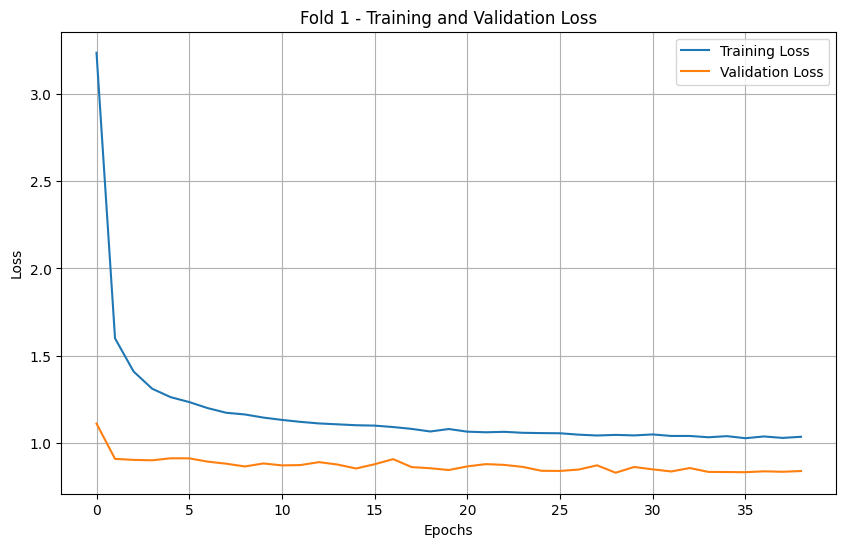

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Model Results for Housing (Fold 1):
Train Data: {'MSE': 17259.522495454792, 'MAE': 90.23942727341684, 'R2': 0.884258533477243, 'RMSE': 131.3755018846923}
Validation Data: {'MSE': 17346.386530654923, 'MAE': 89.7970147419613, 'R2': 0.8781067012396551, 'RMSE': 131.70568146687873}
Test Data: {'MSE': 16996.407482170383, 'MAE': 90.25136743606825, 'R2': 0.8849165898458783, 'RMSE': 130.37027069915283}

Model Results for Food (Fold 1):
Train Data: {'MSE': 4737.393465850537, 'MAE': 46.26890861931175, 'R2': 0.9593760060603117, 'RMSE': 68.82872558641876}
Validation Data: {'MSE': 4092.129028943204, 'MAE': 44.69825344103899, 'R2': 0.9641819211819619, 'RMSE': 63.969750890113716}
Test Data: {'MSE': 5478.7781684914125, 'MAE': 47.27267145344379, 'R2': 0.9533259777065789, 'RMSE': 74.01876902847961}

Model Results for Transportation (Fold 1):
Train Data: {'MSE': 17584.733453095676, 'MAE':

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28            │ (None, 10, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_13 (Conv1D)        │ (None, 10, 8)          │             32 │ input_layer_28[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_13 (Flatten)      │ (None, 80)             │              0 │ conv1d_13[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_56 (Dense)          │ (None, 128)            │         10,368 │ flatten_13[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_56    │ (None, 128)            │            512 │ dense_56[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_56             │ (None, 128)            │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_56 (Dropout)      │ (None, 128)            │              0 │ activation_56[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_57 (Dense)          │ (None, 64)             │          8,256 │ dropout_56[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_57    │ (None, 64)             │            256 │ dense_57[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_57             │ (None, 64)             │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_57 (Dropout)      │ (None, 64)             │              0 │ activation_57[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dropout_57[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dropout_57[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dropout_57[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dropout_57[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dropout_57[0][0]       │
│ (Dense)                   │                        │                │                        │
├──────────────────────

 Total params: 19,879 (77.65 KB)

 Trainable params: 19,495 (76.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 4.1230 - target_childcare_loss: 0.5341 - target_food_loss: 0.5896 - target_healthcare_loss: 0.6554 - target_housing_loss: 0.6023 - target_othernecessities_loss: 0.4590 - target_taxes_loss: 0.5333 - target_transportation_loss: 0.7493 - val_loss: 1.1645 - val_target_childcare_loss: 0.1169 - val_target_food_loss: 0.0661 - val_target_healthcare_loss: 0.2302 - val_target_housing_loss: 0.1919 - val_target_othernecessities_loss: 0.0999 - val_target_taxes_loss: 0.0950 - val_target_transportation_loss: 0.3658
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5821 - target_childcare_loss: 0.1880 - target_food_loss: 0.1494 - target_healthcare_loss: 0.2826 - target_housing_loss: 0.2544 - target_othernecessities_loss: 0.1533 - target_taxes_loss: 0.1562 - target_transportation_loss: 0.3983 - val_loss: 0.9775 - val_target_childcare_loss: 0.0980 - val_target_food_loss: 0.0490 - val_target_healthcare_loss: 0.1974 - val_target_hou

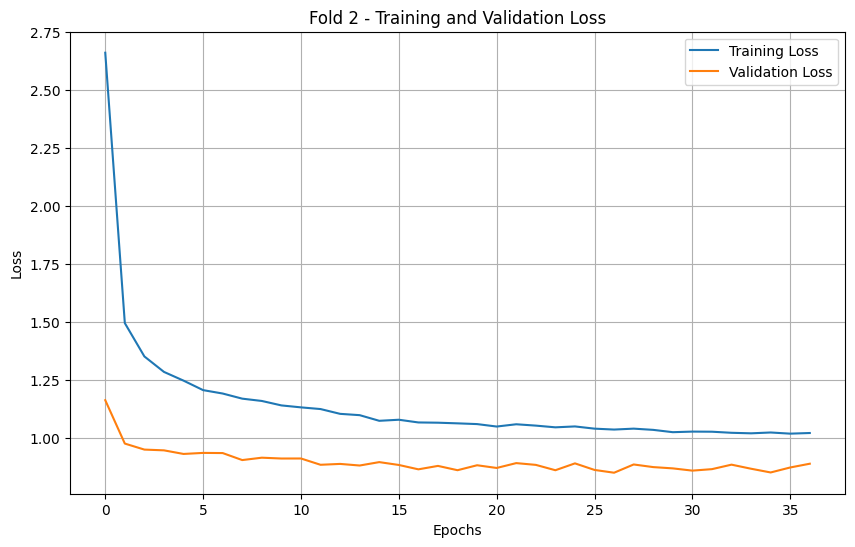

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 2):
Train Data: {'MSE': 16938.22242107956, 'MAE': 91.61799961421431, 'R2': 0.8823808154106485, 'RMSE': 130.1469262836413}
Validation Data: {'MSE': 18726.090490497372, 'MAE': 94.16080377028317, 'R2': 0.8864972031290461, 'RMSE': 136.8433063415868}
Test Data: {'MSE': 18430.39881314366, 'MAE': 93.39751144734454, 'R2': 0.8888182332997863, 'RMSE': 135.75860493222393}

Model Results for Food (Fold 2):
Train Data: {'MSE': 4733.801028872807, 'MAE': 45.437117726796, 'R2': 0.9591339888919534, 'RMSE': 68.8026237063152}
Validation Data: {'MSE': 4424.9066247158535, 'MAE': 45.06345272519351, 'R2': 0.9636032900432056, 'RMSE': 66.51997162293331}
Test Data: {'MSE': 4648.065424879088, 'MAE': 45.759057904594535, 'R2': 0.9600536955247914, 'RMSE': 68.17672201623577}

Model Results for Transportation (Fold 2):
Train Data: {'MSE': 17580.122446812573, 'MAE': 98.

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29            │ (None, 10, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_14 (Conv1D)        │ (None, 10, 8)          │             32 │ input_layer_29[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_14 (Flatten)      │ (None, 80)             │              0 │ conv1d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_58 (Dense)          │ (None, 128)            │         10,368 │ flatten_14[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_58    │ (None, 128)            │            512 │ dense_58[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_58             │ (None, 128)            │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_58 (Dropout)      │ (None, 128)            │              0 │ activation_58[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_59 (Dense)          │ (None, 64)             │          8,256 │ dropout_58[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_59    │ (None, 64)             │            256 │ dense_59[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_59             │ (None, 64)             │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_59 (Dropout)      │ (None, 64)             │              0 │ activation_59[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dropout_59[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dropout_59[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dropout_59[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dropout_59[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dropout_59[0][0]       │
│ (Dense)                   │                        │                │                        │
├──────────────────────

 Total params: 19,879 (77.65 KB)

 Trainable params: 19,495 (76.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 4.3438 - target_childcare_loss: 0.5746 - target_food_loss: 0.4554 - target_healthcare_loss: 0.6668 - target_housing_loss: 0.7255 - target_othernecessities_loss: 0.4943 - target_taxes_loss: 0.6578 - target_transportation_loss: 0.7694 - val_loss: 1.0747 - val_target_childcare_loss: 0.1212 - val_target_food_loss: 0.0690 - val_target_healthcare_loss: 0.2140 - val_target_housing_loss: 0.1591 - val_target_othernecessities_loss: 0.0830 - val_target_taxes_loss: 0.0834 - val_target_transportation_loss: 0.3473
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.6181 - target_childcare_loss: 0.1886 - target_food_loss: 0.1335 - target_healthcare_loss: 0.2819 - target_housing_loss: 0.2698 - target_othernecessities_loss: 0.1534 - target_taxes_loss: 0.1733 - target_transportation_loss: 0.4175 - val_loss: 0.9381 - val_target_childcare_loss: 0.0974 - val_target_food_loss: 0.0484 - val_target_healthcare_loss: 0.2000 - val_target_h

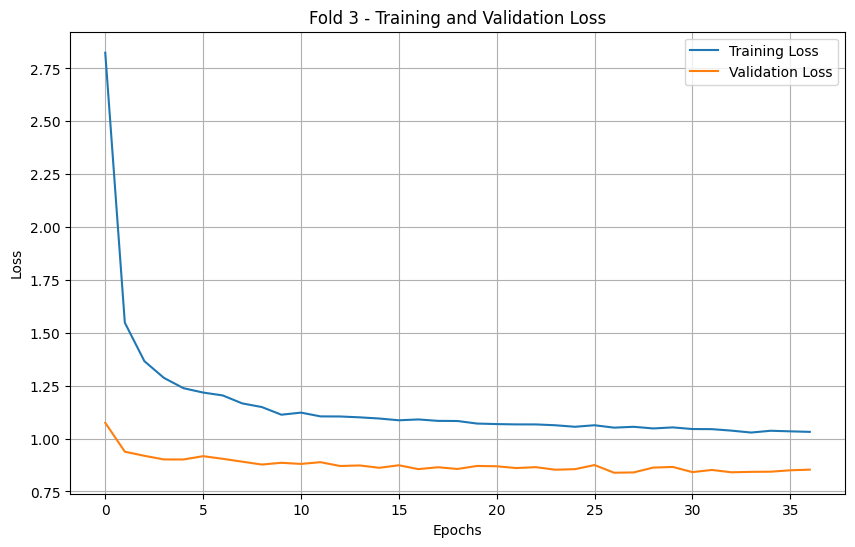

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 3):
Train Data: {'MSE': 17226.42485866821, 'MAE': 91.99873215144052, 'R2': 0.8846000804693016, 'RMSE': 131.24947565102198}
Validation Data: {'MSE': 17349.759747123637, 'MAE': 92.91323455412449, 'R2': 0.8788688771453906, 'RMSE': 131.71848673259058}
Test Data: {'MSE': 17456.823947014123, 'MAE': 92.22894176418828, 'R2': 0.8800785142883091, 'RMSE': 132.12427463193174}

Model Results for Food (Fold 3):
Train Data: {'MSE': 4691.282293790039, 'MAE': 46.26954996301382, 'R2': 0.9598328804061157, 'RMSE': 68.49293608679686}
Validation Data: {'MSE': 5314.152777011326, 'MAE': 48.04657649478069, 'R2': 0.9549520724841462, 'RMSE': 72.89823576062267}
Test Data: {'MSE': 4768.847817253791, 'MAE': 45.93987428311364, 'R2': 0.9575353294543456, 'RMSE': 69.05684482550437}

Model Results for Transportation (Fold 3):
Train Data: {'MSE': 17744.757362714354, 'MAE':

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30            │ (None, 10, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_15 (Conv1D)        │ (None, 10, 8)          │             32 │ input_layer_30[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_15 (Flatten)      │ (None, 80)             │              0 │ conv1d_15[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_60 (Dense)          │ (None, 128)            │         10,368 │ flatten_15[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_60    │ (None, 128)            │            512 │ dense_60[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_60             │ (None, 128)            │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_60 (Dropout)      │ (None, 128)            │              0 │ activation_60[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_61 (Dense)          │ (None, 64)             │          8,256 │ dropout_60[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_61    │ (None, 64)             │            256 │ dense_61[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_61             │ (None, 64)             │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_61 (Dropout)      │ (None, 64)             │              0 │ activation_61[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dropout_61[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dropout_61[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dropout_61[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dropout_61[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dropout_61[0][0]       │
│ (Dense)                   │                        │                │                        │
├──────────────────────

 Total params: 19,879 (77.65 KB)

 Trainable params: 19,495 (76.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 4.6632 - target_childcare_loss: 0.6513 - target_food_loss: 0.5372 - target_healthcare_loss: 0.6092 - target_housing_loss: 0.7969 - target_othernecessities_loss: 0.6493 - target_taxes_loss: 0.5841 - target_transportation_loss: 0.8351 - val_loss: 0.9717 - val_target_childcare_loss: 0.0959 - val_target_food_loss: 0.0564 - val_target_healthcare_loss: 0.1927 - val_target_housing_loss: 0.1548 - val_target_othernecessities_loss: 0.0695 - val_target_taxes_loss: 0.0683 - val_target_transportation_loss: 0.3260
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.6305 - target_childcare_loss: 0.1857 - target_food_loss: 0.1377 - target_healthcare_loss: 0.2843 - target_housing_loss: 0.2624 - target_othernecessities_loss: 0.1599 - target_taxes_loss: 0.1623 - target_transportation_loss: 0.4381 - val_loss: 0.8843 - val_target_childcare_loss: 0.0888 - val_target_food_loss: 0.0440 - val_target_healthcare_loss: 0.1824 - val_target_hou

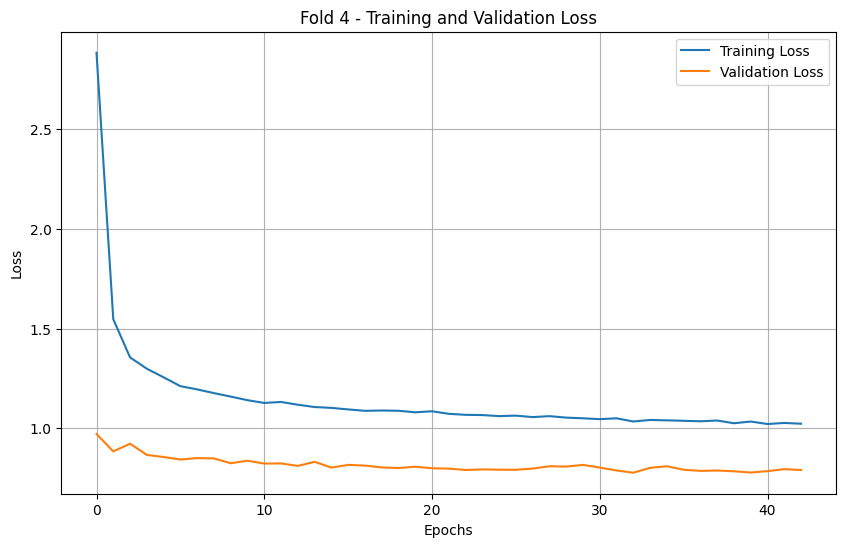

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 4):
Train Data: {'MSE': 17156.60356635033, 'MAE': 91.70669220436768, 'R2': 0.8850031113451673, 'RMSE': 130.98321864403215}
Validation Data: {'MSE': 16517.130378735183, 'MAE': 90.36828774462222, 'R2': 0.8781337940717536, 'RMSE': 128.51898839757175}
Test Data: {'MSE': 18054.296404275705, 'MAE': 93.86552519984888, 'R2': 0.8825905447770617, 'RMSE': 134.36627703510916}

Model Results for Food (Fold 4):
Train Data: {'MSE': 4828.8560799071265, 'MAE': 46.24323101571666, 'R2': 0.9585625867841733, 'RMSE': 69.48997107430054}
Validation Data: {'MSE': 4222.8044735809535, 'MAE': 44.969672829036, 'R2': 0.963682107526604, 'RMSE': 64.98310914061402}
Test Data: {'MSE': 4371.275744404061, 'MAE': 45.8772013534075, 'R2': 0.9622956830517754, 'RMSE': 66.11562405667863}

Model Results for Transportation (Fold 4):
Train Data: {'MSE': 17697.230926568103, 'MAE': 9

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31            │ (None, 10, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_16 (Conv1D)        │ (None, 10, 8)          │             32 │ input_layer_31[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_16 (Flatten)      │ (None, 80)             │              0 │ conv1d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_62 (Dense)          │ (None, 128)            │         10,368 │ flatten_16[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_62    │ (None, 128)            │            512 │ dense_62[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_62             │ (None, 128)            │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_62 (Dropout)      │ (None, 128)            │              0 │ activation_62[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_63 (Dense)          │ (None, 64)             │          8,256 │ dropout_62[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_63    │ (None, 64)             │            256 │ dense_63[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_63             │ (None, 64)             │              0 │ batch_normalization_6… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_63 (Dropout)      │ (None, 64)             │              0 │ activation_63[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_housing (Dense)    │ (None, 1)              │             65 │ dropout_63[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_food (Dense)       │ (None, 1)              │             65 │ dropout_63[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_transportation     │ (None, 1)              │             65 │ dropout_63[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_healthcare (Dense) │ (None, 1)              │             65 │ dropout_63[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ target_othernecessities   │ (None, 1)              │             65 │ dropout_63[0][0]       │
│ (Dense)                   │                        │                │                        │
├──────────────────────

 Total params: 19,879 (77.65 KB)

 Trainable params: 19,495 (76.15 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 4.4786 - target_childcare_loss: 0.5636 - target_food_loss: 0.5188 - target_healthcare_loss: 0.6952 - target_housing_loss: 0.7355 - target_othernecessities_loss: 0.5844 - target_taxes_loss: 0.5593 - target_transportation_loss: 0.8217 - val_loss: 1.0851 - val_target_childcare_loss: 0.0972 - val_target_food_loss: 0.0755 - val_target_healthcare_loss: 0.2193 - val_target_housing_loss: 0.1808 - val_target_othernecessities_loss: 0.0890 - val_target_taxes_loss: 0.0900 - val_target_transportation_loss: 0.3264
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.6431 - target_childcare_loss: 0.1906 - target_food_loss: 0.1376 - target_healthcare_loss: 0.2938 - target_housing_loss: 0.2579 - target_othernecessities_loss: 0.1656 - target_taxes_loss: 0.1653 - target_transportation_loss: 0.4322 - val_loss: 0.8843 - val_target_childcare_loss: 0.0837 - val_target_food_loss: 0.0515 - val_target_healthcare_loss: 0.1865 - val_target_hou

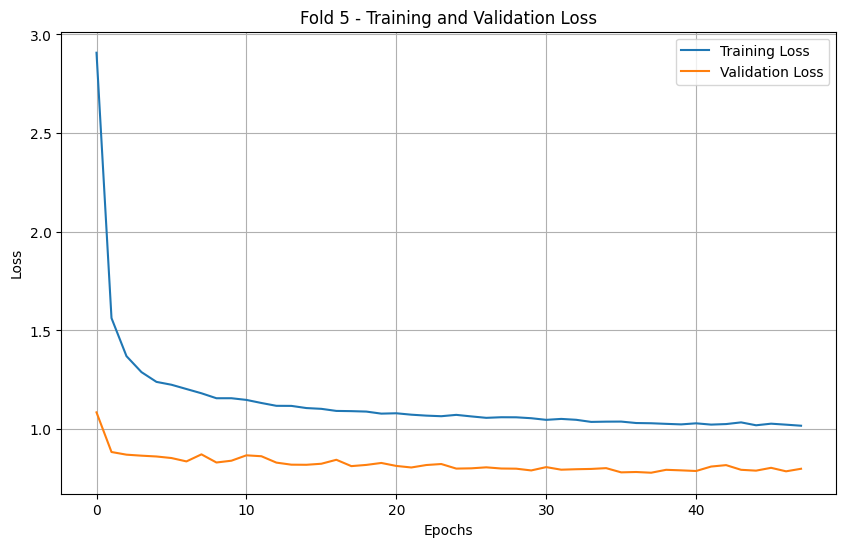

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model Results for Housing (Fold 5):
Train Data: {'MSE': 16934.1534738943, 'MAE': 89.07832745204031, 'R2': 0.887035895656279, 'RMSE': 130.13129321533043}
Validation Data: {'MSE': 16511.813106906124, 'MAE': 89.49803205800215, 'R2': 0.8751484683762374, 'RMSE': 128.49830001562714}
Test Data: {'MSE': 16707.247956515886, 'MAE': 88.71249033302553, 'R2': 0.8897018884513068, 'RMSE': 129.25651997681157}

Model Results for Food (Fold 5):
Train Data: {'MSE': 4566.120269049607, 'MAE': 46.24968708801755, 'R2': 0.9608174940242584, 'RMSE': 67.57307355041361}
Validation Data: {'MSE': 5505.8369328772915, 'MAE': 48.2902617932428, 'R2': 0.9527202750563291, 'RMSE': 74.20132702908548}
Test Data: {'MSE': 4430.063722841009, 'MAE': 46.33351526069216, 'R2': 0.9617606002730108, 'RMSE': 66.55872386728136}

Model Results for Transportation (Fold 5):
Train Data: {'MSE': 18043.76015465866, 'MAE': 98

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Add to the function to plot training and validation loss curves
def plot_loss_curves(history, fold):
    """
    Plot the training and validation loss curves for a given training history.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} - Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to calculate regression metrics
def regr_report(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Cross-validation function with evaluation
def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y, num_epochs=200):
    fold = 1
    target_metrics = {target: {"train": [], "val": [], "test": []} for target in target_col_list}

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data (50/50 split of remaining 20%)
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )

        # Reshaping data for CNN input
        X_train = X_train[..., np.newaxis]
        X_val = X_val[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        # Create model
        model = create_hybrid_model((X_train.shape[1], 1), target_col_list)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # Model summary
        model.summary()

        # Train model
        history = model.fit(
            X_train,
            [y_train[:, i] for i in range(y_train.shape[1])],
            validation_data=(X_val, [y_val[:, i] for i in range(y_val.shape[1])]),
            epochs=num_epochs,
            batch_size=64,
            verbose=1,
            callbacks=[early_stopping]
        )
        plot_loss_curves(history, fold)

        # Predictions
        y_train_pred = np.column_stack(model.predict(X_train))
        y_val_pred = np.column_stack(model.predict(X_val))
        y_test_pred = np.column_stack(model.predict(X_test))

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            train_metrics = regr_report(y_train_original[:, i], y_train_pred_original[:, i])
            val_metrics = regr_report(y_val_original[:, i], y_val_pred_original[:, i])
            test_metrics = regr_report(y_test_original[:, i], y_test_pred_original[:, i])

            print(f'Model Results for {target.capitalize()} (Fold {fold}):')
            print("Train Data:", train_metrics)
            print("Validation Data:", val_metrics)
            print("Test Data:", test_metrics)
            print()

            # Append metrics for the target
            target_metrics[target]["train"].append(train_metrics)
            target_metrics[target]["val"].append(val_metrics)
            target_metrics[target]["test"].append(test_metrics)

        fold += 1

    # Final evaluation: average metrics for each target across folds
    print("\nFinal Evaluation Across All Folds for Each Target:")
    for target, metrics in target_metrics.items():
        print(f"\nTarget: {target.capitalize()}")
        for dataset, dataset_metrics in metrics.items():
            avg_metrics = {k: np.mean([fold_metrics[k] for fold_metrics in dataset_metrics]) for k in dataset_metrics[0]}
            print(f"{dataset.capitalize()} Data: {avg_metrics}")

    return model

# Cross-validation execution
model = cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y)
model.save_weights("model_expenses.weights.h5")


**Deep Boost Regressor**

Fold 1/5
Epoch 1/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5.1019 - target_childcare_loss: 0.6815 - target_food_loss: 0.6394 - target_healthcare_loss: 0.7551 - target_housing_loss: 0.9026 - target_othernecessities_loss: 0.5636 - target_taxes_loss: 0.6769 - target_transportation_loss: 0.8827 - val_loss: 1.8948 - val_target_childcare_loss: 0.2677 - val_target_food_loss: 0.1615 - val_target_healthcare_loss: 0.2749 - val_target_housing_loss: 0.3220 - val_target_othernecessities_loss: 0.1811 - val_target_taxes_loss: 0.2403 - val_target_transportation_loss: 0.4471
Epoch 2/200
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8474 - target_childcare_loss: 0.2240 - target_food_loss: 0.1632 - target_healthcare_loss: 0.3206 - target_housing_loss: 0.3143 - target_othernecessities_loss: 0.1892 - target_taxes_loss: 0.2012 - target_transportation_loss: 0.4348 - val_loss: 1.0354 - val_target_childcare_loss: 0.1150 - val_target_food_loss: 0.0471 - val_target_healthcare_loss: 0.1886 - val_t

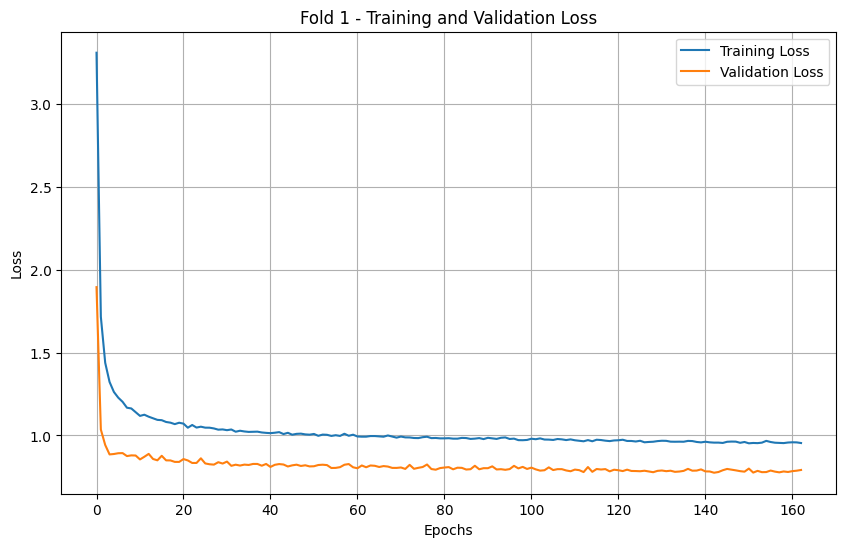

786/786 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Metrics for Housing (Fold 1):
  Train MSE: 6155.37, MAE: 56.23, R²: 0.96, RMSE: 78.46
  Val MSE: 8659.79, MAE: 65.46, R²: 0.94, RMSE: 93.06
  Test MSE: 8554.96, MAE: 65.54, R²: 0.94, RMSE: 92.49
Metrics for Food (Fold 1):
  Train MSE: 1750.87, MAE: 29.16, R²: 0.98, RMSE: 41.84
  Val MSE: 2321.70, MAE: 33.18, R²: 0.98, RMSE: 48.18
  Test MSE: 3250.45, MAE: 34.89, R²: 0.97, RMSE: 57.01
Metrics for Transportation (Fold 1):
  Train MSE: 6923.12, MAE: 62.84, R²: 0.88, RMSE: 83.21
  Val MSE: 10435.48, MAE: 74.85, R²: 0.82, RMSE: 102.15
  Test MSE: 10114.90, MAE: 74.70, R²: 0.83, RMSE: 100.57
Metrics for Healthcare (Fold 1):
  Train MSE: 11962.94, MAE: 78.45, R²: 0.95, RMSE: 109.38
  Val MSE: 14901.77, MAE: 86.23, R²: 0.94, RMSE: 122.07
  Test MSE: 15126.38, MAE: 87.92, R²: 0.94, RMSE: 122.99
Metrics for Othernecessities (Fold 1):
  Train MSE: 973.26, MAE: 22.70, R²: 0.98, RM

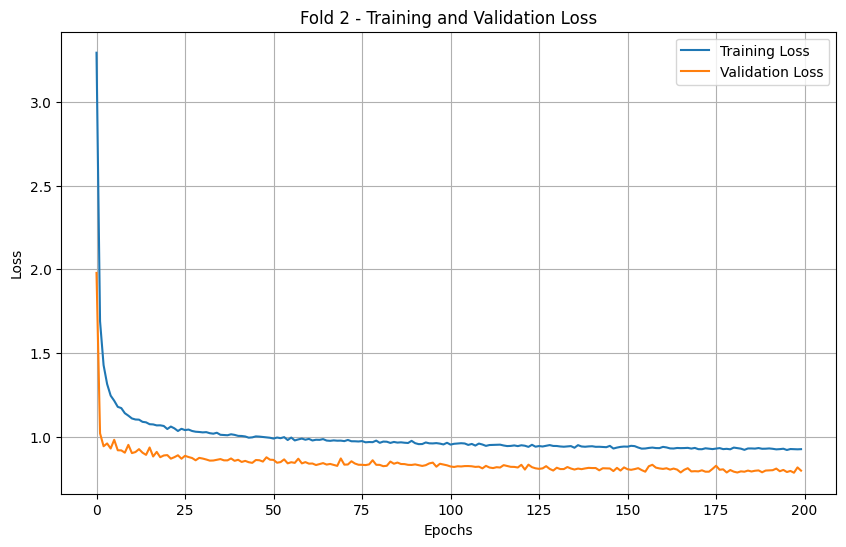

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metrics for Housing (Fold 2):
  Train MSE: 5891.32, MAE: 55.48, R²: 0.96, RMSE: 76.75
  Val MSE: 9238.93, MAE: 66.03, R²: 0.94, RMSE: 96.12
  Test MSE: 9632.59, MAE: 67.03, R²: 0.94, RMSE: 98.15
Metrics for Food (Fold 2):
  Train MSE: 1700.17, MAE: 28.86, R²: 0.99, RMSE: 41.23
  Val MSE: 2475.12, MAE: 33.45, R²: 0.98, RMSE: 49.75
  Test MSE: 2605.36, MAE: 33.81, R²: 0.98, RMSE: 51.04
Metrics for Transportation (Fold 2):
  Train MSE: 7018.31, MAE: 63.49, R²: 0.88, RMSE: 83.78
  Val MSE: 10458.97, MAE: 73.41, R²: 0.82, RMSE: 102.27
  Test MSE: 9577.14, MAE: 72.66, R²: 0.83, RMSE: 97.86
Metrics for Healthcare (Fold 2):
  Train MSE: 11229.18, MAE: 76.30, R²: 0.95, RMSE: 105.97
  Val MSE: 15520.39, MAE: 87.17, R²: 0.94, RMSE: 124.58
  Test MSE: 16119.98, MAE: 88.76, R²: 0.93, RMSE: 126.96
Metrics for Othernecessities (Fold 2):
  Train MSE: 937.68, MAE: 22.35, R²: 0.98, RMSE

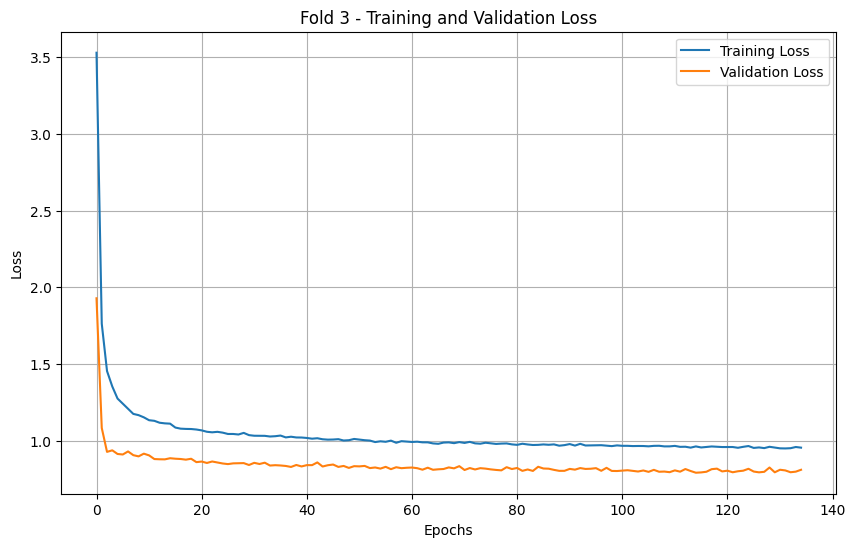

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metrics for Housing (Fold 3):
  Train MSE: 6068.62, MAE: 55.87, R²: 0.96, RMSE: 77.90
  Val MSE: 8918.82, MAE: 66.85, R²: 0.94, RMSE: 94.44
  Test MSE: 9148.68, MAE: 66.32, R²: 0.94, RMSE: 95.65
Metrics for Food (Fold 3):
  Train MSE: 1750.47, MAE: 29.14, R²: 0.99, RMSE: 41.84
  Val MSE: 2953.94, MAE: 35.56, R²: 0.97, RMSE: 54.35
  Test MSE: 2668.17, MAE: 34.00, R²: 0.98, RMSE: 51.65
Metrics for Transportation (Fold 3):
  Train MSE: 7035.85, MAE: 63.30, R²: 0.88, RMSE: 83.88
  Val MSE: 9892.43, MAE: 74.27, R²: 0.83, RMSE: 99.46
  Test MSE: 9787.40, MAE: 72.96, R²: 0.82, RMSE: 98.93
Metrics for Healthcare (Fold 3):
  Train MSE: 11596.42, MAE: 77.50, R²: 0.95, RMSE: 107.69
  Val MSE: 15824.16, MAE: 88.60, R²: 0.94, RMSE: 125.79
  Test MSE: 16934.70, MAE: 91.29, R²: 0.93, RMSE: 130.13
Metrics for Othernecessities (Fold 3):
  Train MSE: 968.17, MAE: 22.50, R²: 0.98, RMSE: 

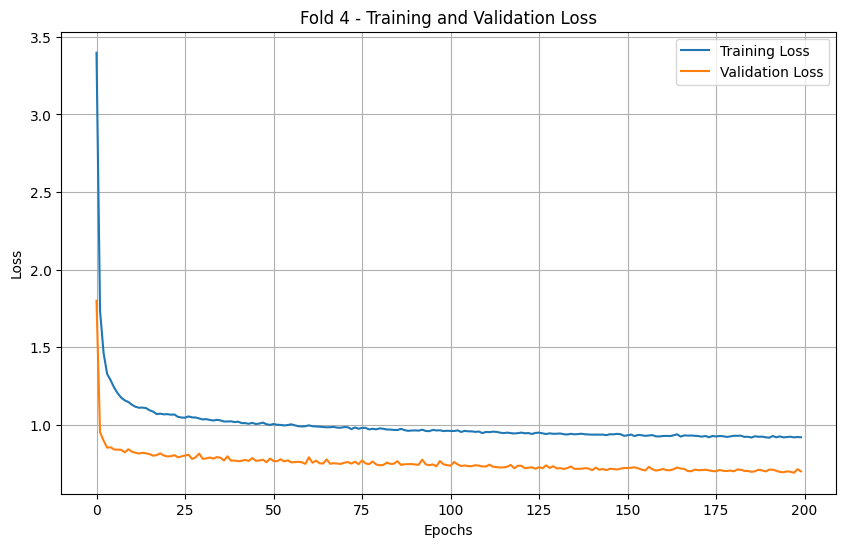

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metrics for Housing (Fold 4):
  Train MSE: 5863.03, MAE: 54.69, R²: 0.96, RMSE: 76.57
  Val MSE: 8352.32, MAE: 63.60, R²: 0.94, RMSE: 91.39
  Test MSE: 8924.44, MAE: 65.98, R²: 0.94, RMSE: 94.47
Metrics for Food (Fold 4):
  Train MSE: 1707.22, MAE: 28.69, R²: 0.99, RMSE: 41.32
  Val MSE: 2301.23, MAE: 33.19, R²: 0.98, RMSE: 47.97
  Test MSE: 2359.02, MAE: 33.22, R²: 0.98, RMSE: 48.57
Metrics for Transportation (Fold 4):
  Train MSE: 6868.05, MAE: 62.87, R²: 0.88, RMSE: 82.87
  Val MSE: 9160.78, MAE: 71.50, R²: 0.84, RMSE: 95.71
  Test MSE: 9926.53, MAE: 73.87, R²: 0.82, RMSE: 99.63
Metrics for Healthcare (Fold 4):
  Train MSE: 10726.80, MAE: 74.76, R²: 0.96, RMSE: 103.57
  Val MSE: 14045.73, MAE: 82.80, R²: 0.94, RMSE: 118.51
  Test MSE: 13383.98, MAE: 83.64, R²: 0.94, RMSE: 115.69
Metrics for Othernecessities (Fold 4):
  Train MSE: 920.17, MAE: 21.94, R²: 0.98, RMSE: 

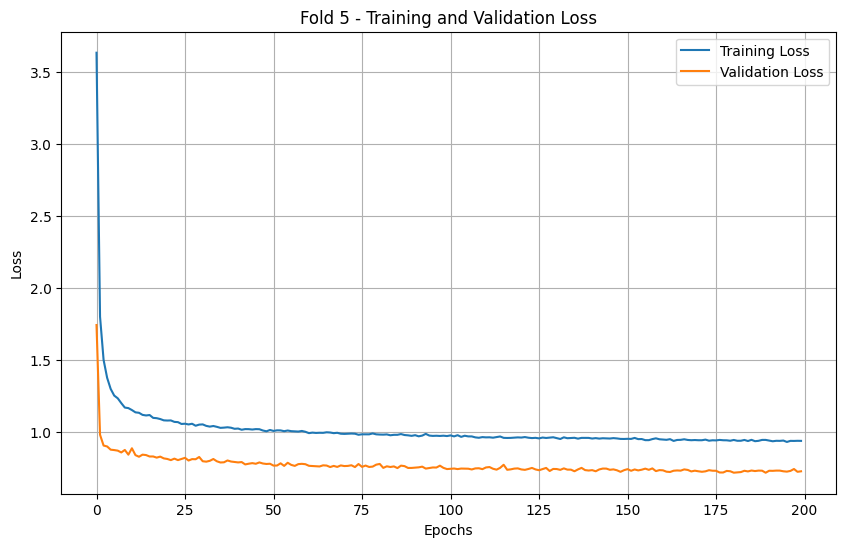

786/786 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metrics for Housing (Fold 5):
  Train MSE: 5995.80, MAE: 55.61, R²: 0.96, RMSE: 77.43
  Val MSE: 8464.00, MAE: 64.72, R²: 0.94, RMSE: 92.00
  Test MSE: 8927.90, MAE: 65.49, R²: 0.94, RMSE: 94.49
Metrics for Food (Fold 5):
  Train MSE: 1682.83, MAE: 29.06, R²: 0.99, RMSE: 41.02
  Val MSE: 3140.68, MAE: 36.07, R²: 0.97, RMSE: 56.04
  Test MSE: 2577.63, MAE: 34.31, R²: 0.98, RMSE: 50.77
Metrics for Transportation (Fold 5):
  Train MSE: 6988.09, MAE: 63.09, R²: 0.88, RMSE: 83.59
  Val MSE: 9262.17, MAE: 71.86, R²: 0.83, RMSE: 96.24
  Test MSE: 9538.92, MAE: 71.68, R²: 0.83, RMSE: 97.67
Metrics for Healthcare (Fold 5):
  Train MSE: 11028.95, MAE: 75.66, R²: 0.95, RMSE: 105.02
  Val MSE: 14703.69, MAE: 86.87, R²: 0.94, RMSE: 121.26
  Test MSE: 13821.62, MAE: 83.62, R²: 0.94, RMSE: 117.57
Metrics for Othernecessities (Fold 5):
  Train MSE: 936.89, MAE: 22.36, R²: 0.98, RMSE: 

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb

def create_xgboost_model(X_train, y_train):
    xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.1)
    xg_reg.fit(X_train, y_train)
    return xg_reg

def plot_loss_curves(history, fold):
    """
    Plot the training and validation loss curves for a given training history.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} - Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y, num_epochs=200):
    fold = 1
    metrics_per_fold = {target: {"train": [], "val": [], "test": []} for target in target_col_list}

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )

        # Reshape for CNN
        X_train_cnn = X_train[..., np.newaxis]
        X_val_cnn = X_val[..., np.newaxis]
        X_test_cnn = X_test[..., np.newaxis]

        # Create and compile the hybrid model
        model = create_hybrid_model((X_train_cnn.shape[1], 1), target_col_list)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

        # Train the CNN-ANN part
        history = model.fit(
            X_train_cnn,
            [y_train[:, i] for i in range(y_train.shape[1])],
            validation_data=(X_val_cnn, [y_val[:, i] for i in range(y_val.shape[1])]),
            epochs=num_epochs,
            batch_size=128,
            verbose=1,
            callbacks=[early_stopping]
        )

        # Plot the loss curves
        plot_loss_curves(history, fold)

        # Predictions from the CNN-ANN model
        y_train_cnn_pred = np.column_stack(model.predict(X_train_cnn))
        y_val_cnn_pred = np.column_stack(model.predict(X_val_cnn))
        y_test_cnn_pred = np.column_stack(model.predict(X_test_cnn))

        # Create XGBoost model
        xgboost_models = []
        for i in range(y_train.shape[1]):
            xg_model = create_xgboost_model(X_train, y_train[:, i])
            xgboost_models.append(xg_model)

        # Predictions from each XGBoost model
        y_train_xgb_pred = np.column_stack([model.predict(X_train) for model in xgboost_models])
        y_val_xgb_pred = np.column_stack([model.predict(X_val) for model in xgboost_models])
        y_test_xgb_pred = np.column_stack([model.predict(X_test) for model in xgboost_models])

        # Combine predictions
        y_train_pred = (y_train_cnn_pred + y_train_xgb_pred) / 2
        y_val_pred = (y_val_cnn_pred + y_val_xgb_pred) / 2
        y_test_pred = (y_test_cnn_pred + y_test_xgb_pred) / 2

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            train_mse = mean_squared_error(y_train_original[:, i], y_train_pred_original[:, i])
            val_mse = mean_squared_error(y_val_original[:, i], y_val_pred_original[:, i])
            test_mse = mean_squared_error(y_test_original[:, i], y_test_pred_original[:, i])

            train_mae = mean_absolute_error(y_train_original[:, i], y_train_pred_original[:, i])
            val_mae = mean_absolute_error(y_val_original[:, i], y_val_pred_original[:, i])
            test_mae = mean_absolute_error(y_test_original[:, i], y_test_pred_original[:, i])

            train_r2 = r2_score(y_train_original[:, i], y_train_pred_original[:, i])
            val_r2 = r2_score(y_val_original[:, i], y_val_pred_original[:, i])
            test_r2 = r2_score(y_test_original[:, i], y_test_pred_original[:, i])

            train_rmse = np.sqrt(train_mse)
            val_rmse = np.sqrt(val_mse)
            test_rmse = np.sqrt(test_mse)

            metrics_per_fold[target]["train"].append((train_mse, train_mae, train_r2, train_rmse))
            metrics_per_fold[target]["val"].append((val_mse, val_mae, val_r2, val_rmse))
            metrics_per_fold[target]["test"].append((test_mse, test_mae, test_r2, test_rmse))



            print(f'Metrics for {target.capitalize()} (Fold {fold}):')
            print(f'  Train MSE: {train_mse:.2f}, MAE: {train_mae:.2f}, R²: {train_r2:.2f}, RMSE: {train_rmse:.2f}')
            print(f'  Val MSE: {val_mse:.2f}, MAE: {val_mae:.2f}, R²: {val_r2:.2f}, RMSE: {val_rmse:.2f}')
            print(f'  Test MSE: {test_mse:.2f}, MAE: {test_mae:.2f}, R²: {test_r2:.2f}, RMSE: {test_rmse:.2f}')

        fold += 1

    # Average metrics across all folds
    print("\nAverage Metrics Across Folds:")
    for target in target_col_list:
        avg_metrics_train = np.mean(metrics_per_fold[target]["train"], axis=0)
        avg_metrics_val = np.mean(metrics_per_fold[target]["val"], axis=0)
        avg_metrics_test = np.mean(metrics_per_fold[target]["test"], axis=0)

        print(f'Average Metrics for {target.capitalize()}:')

        print(f'  Train MSE: {avg_metrics_train[0]:.2f}, MAE: {avg_metrics_train[1]:.2f}, R²: {avg_metrics_train[2]:.2f}, RMSE: {avg_metrics_train[3]:.2f}')
        print(f'  Val MSE: {avg_metrics_val[0]:.2f}, MAE: {avg_metrics_val[1]:.2f}, R²: {avg_metrics_val[2]:.2f}, RMSE: {avg_metrics_val[3]:.2f}')
        print(f'  Test MSE: {avg_metrics_test[0]:.2f}, MAE: {avg_metrics_test[1]:.2f}, R²: {avg_metrics_test[2]:.2f}, RMSE: {avg_metrics_test[3]:.2f}')

    return model

# Cross-Validation Execution
model = cross_val_with_evaluation(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y)
model.save_weights("model_expenses.weights.h5")


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define evaluation function for regression metrics
def regr_report(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Cross-validation with Random Forest Regression
def cross_val_with_rf(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y, n_estimators=100, random_state=42):
    fold = 1
    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data (50/50 split of remaining 20%)
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )

        # Initialize models for each target column
        rf_models = [
            RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
            for _ in target_col_list
        ]

        # Train Random Forest for each target
        for i, target in enumerate(target_col_list):
            rf_models[i].fit(X_train, y_train[:, i])

        # Predictions for train, validation, and test sets
        y_train_pred = np.column_stack([model.predict(X_train) for model in rf_models])
        y_val_pred = np.column_stack([model.predict(X_val) for model in rf_models])
        y_test_pred = np.column_stack([model.predict(X_test) for model in rf_models])

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Metrics for each target
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')
            print('Train Data:', regr_report(y_train_original[:, i], y_train_pred_original[:, i]))
            print('Validation Data:', regr_report(y_val_original[:, i], y_val_pred_original[:, i]))
            print('Test Data:', regr_report(y_test_original[:, i], y_test_pred_original[:, i]))
            print()

        fold += 1

    return rf_models

# Cross-Validation Execution
rf_models = cross_val_with_rf(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y)


Fold 1/5
Model Results for Housing:
Train Data: {'MSE': 1712.0381311525603, 'R2': 0.9885191607071018, 'MAE': 27.298337177855526, 'RMSE': 41.376782513295545}
Validation Data: {'MSE': 11773.807689277757, 'R2': 0.9172652900545163, 'MAE': 73.58891504931593, 'RMSE': 108.50717805416265}
Test Data: {'MSE': 11911.817626026092, 'R2': 0.9193445676696612, 'MAE': 72.84327076041997, 'RMSE': 109.14127370534986}

Model Results for Food:
Train Data: {'MSE': 471.41371082564416, 'R2': 0.9959575433474727, 'MAE': 14.298649379573655, 'RMSE': 21.712063716414526}
Validation Data: {'MSE': 3085.3196345847914, 'R2': 0.9729944434623711, 'MAE': 38.330687241489024, 'RMSE': 55.545653606603565}
Test Data: {'MSE': 4139.4686877187405, 'R2': 0.964735631217078, 'MAE': 39.15342984409799, 'RMSE': 64.33870287563109}

Model Results for Transportation:
Train Data: {'MSE': 2010.3384256721286, 'R2': 0.9642638494055314, 'MAE': 32.18057468978682, 'RMSE': 44.836797674144044}
Validation Data: {'MSE': 14856.867788577792, 'R2': 0.73

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.model_selection import train_test_split

# Define evaluation function for regression metrics
def regr_report(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Cross-validation with Random Forest Regression
def cross_val_with_rf(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y, n_estimators=100, random_state=42):
    fold = 1

    # Lists to store metrics for averaging later
    metrics_per_target = {target: [] for target in target_col_list}

    for train_index, val_index in kf.split(X_scaled):
        print(f"Fold {fold}/{kf.get_n_splits()}")
        X_train, X_test_val = X_scaled[train_index], X_scaled[val_index]
        y_train, y_test_val = y_exp_scaled[train_index], y_exp_scaled[val_index]

        # Split validation and test data (50/50 split of remaining 20%)
        X_test, X_val, y_test, y_val = train_test_split(
            X_test_val, y_test_val, test_size=0.5, random_state=100
        )

        # Initialize models for each target column
        rf_models = [
            RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
            for _ in target_col_list
        ]

        # Train Random Forest for each target
        for i, target in enumerate(target_col_list):
            rf_models[i].fit(X_train, y_train[:, i])

        # Predictions for train, validation, and test sets
        y_train_pred = np.column_stack([model.predict(X_train) for model in rf_models])
        y_val_pred = np.column_stack([model.predict(X_val) for model in rf_models])
        y_test_pred = np.column_stack([model.predict(X_test) for model in rf_models])

        # Inverse scaling
        y_train_pred_original = scaler_y.inverse_transform(y_train_pred)
        y_train_original = scaler_y.inverse_transform(y_train)
        y_val_pred_original = scaler_y.inverse_transform(y_val_pred)
        y_val_original = scaler_y.inverse_transform(y_val)
        y_test_pred_original = scaler_y.inverse_transform(y_test_pred)
        y_test_original = scaler_y.inverse_transform(y_test)

        # Metrics for each target and store them
        for i, target in enumerate(target_col_list):
            print(f'Model Results for {target.capitalize()}:')

            train_metrics = regr_report(y_train_original[:, i], y_train_pred_original[:, i])
            val_metrics = regr_report(y_val_original[:, i], y_val_pred_original[:, i])
            test_metrics = regr_report(y_test_original[:, i], y_test_pred_original[:, i])

            print('Train Data:', train_metrics)
            print('Validation Data:', val_metrics)
            print('Test Data:', test_metrics)
            print()

            # Store metrics for averaging later
            metrics_per_target[target].append((train_metrics, val_metrics, test_metrics))

        fold += 1

    # Calculate average metrics across folds
    avg_metrics_per_target = {}
    for target in target_col_list:
        avg_metrics_per_target[target] = {
            "Train": {
                "MSE": np.mean([metrics[0]["MSE"] for metrics in metrics_per_target[target]]),
                "R2": np.mean([metrics[0]["R2"] for metrics in metrics_per_target[target]]),
                "MAE": np.mean([metrics[0]["MAE"] for metrics in metrics_per_target[target]]),
                "RMSE": np.mean([metrics[0]["RMSE"] for metrics in metrics_per_target[target]])
            },
            "Validation": {
                "MSE": np.mean([metrics[1]["MSE"] for metrics in metrics_per_target[target]]),
                "R2": np.mean([metrics[1]["R2"] for metrics in metrics_per_target[target]]),
                "MAE": np.mean([metrics[1]["MAE"] for metrics in metrics_per_target[target]]),
                "RMSE": np.mean([metrics[1]["RMSE"] for metrics in metrics_per_target[target]])
            },
            "Test": {
                "MSE": np.mean([metrics[2]["MSE"] for metrics in metrics_per_target[target]]),
                "R2": np.mean([metrics[2]["R2"] for metrics in metrics_per_target[target]]),
                "MAE": np.mean([metrics[2]["MAE"] for metrics in metrics_per_target[target]]),
                "RMSE": np.mean([metrics[2]["RMSE"] for metrics in metrics_per_target[target]])
            }
        }

    # Print average evaluation results per target
    print("Average Evaluation Metrics:")
    for target_name, avg_metrics in avg_metrics_per_target.items():
        print(f"Target: {target_name.capitalize()}")
        print("Average Train Metrics:", avg_metrics["Train"])
        print("Average Validation Metrics:", avg_metrics["Validation"])
        print("Average Test Metrics:", avg_metrics["Test"])
        print()

    return rf_models

# Cross-Validation Execution
rf_models = cross_val_with_rf(X_scaled, y_exp_scaled, kf, target_col_list, scaler_y)


Fold 1/5
Model Results for Housing:
Train Data: {'MSE': 1712.0381311525603, 'R2': 0.9885191607071018, 'MAE': 27.298337177855526, 'RMSE': 41.376782513295545}
Validation Data: {'MSE': 11773.807689277757, 'R2': 0.9172652900545163, 'MAE': 73.58891504931593, 'RMSE': 108.50717805416265}
Test Data: {'MSE': 11911.817626026092, 'R2': 0.9193445676696612, 'MAE': 72.84327076041997, 'RMSE': 109.14127370534986}

Model Results for Food:
Train Data: {'MSE': 471.41371082564416, 'R2': 0.9959575433474727, 'MAE': 14.298649379573655, 'RMSE': 21.712063716414526}
Validation Data: {'MSE': 3085.3196345847914, 'R2': 0.9729944434623711, 'MAE': 38.330687241489024, 'RMSE': 55.545653606603565}
Test Data: {'MSE': 4139.4686877187405, 'R2': 0.964735631217078, 'MAE': 39.15342984409799, 'RMSE': 64.33870287563109}

Model Results for Transportation:
Train Data: {'MSE': 2010.3384256721286, 'R2': 0.9642638494055314, 'MAE': 32.18057468978682, 'RMSE': 44.836797674144044}
Validation Data: {'MSE': 14856.867788577792, 'R2': 0.73

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

def get_prediction(model, input_data):
    # Step 1: Preprocess input data (same as training)
    input_data["per_member_cost"] = input_data["total"] / input_data["n_members"]
    input_data["child_expense_cost"] = input_data["per_member_cost"] * input_data["n_children"]
    input_data["parent_expense_cost"] = input_data["per_member_cost"] * input_data["n_parents"]
    input_data["other_expense_cost"] = input_data["total"] - (
        input_data["child_expense_cost"] + input_data["parent_expense_cost"]
    )

    # Convert input data to numpy array
    input_data_val = input_data[['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents',
                                 'n_members', 'per_member_cost', 'child_expense_cost', 'parent_expense_cost', 'other_expense_cost']].values

    # Step 2: Scale the input data using the pre-fitted scaler_X
    input_data_val_scaled = scaler_X.transform(input_data_val)

    # Ensure model expects input in the right shape (if using CNN or RNN, it might need reshaping)
    input_data_val_scaled = input_data_val_scaled[..., np.newaxis]  # If needed

    # Step 3: Make predictions using the trained model
    raw_predictions = model.predict(input_data_val_scaled)

    # Step 3.5: Reshape raw_predictions before inverse scaling
    raw_predictions = np.squeeze(raw_predictions, axis=-1)  # Remove the extra dimension
    raw_predictions = np.column_stack(raw_predictions) # Reshape to 2D

    # Step 4: Inverse transform the predictions to return them to the original scale
    input_data_pred_original = scaler_y.inverse_transform(raw_predictions)

    return input_data_pred_original

# Example of input data to test predictions
input_data = pd.DataFrame(
    [[10191, 87000, 67, 4, 2, 6]],
    columns=['total', 'median_family_income', 'num_counties_in_st', 'n_children', 'n_parents', 'n_members']
)

input_data_pred_original = get_prediction(model, input_data)

# Print predictions
target_col_list = ['housing', 'food', 'transportation', 'healthcare', 'othernecessities', 'childcare', 'taxes']
for i, prediction in enumerate(input_data_pred_original[0]):
    print(f"{target_col_list[i]}: {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
housing: 1249.35
food: 1484.32
transportation: 1805.24
healthcare: 1966.90
othernecessities: 967.53
childcare: 1451.67
taxes: 1346.22
